# Crypto Price Prediction Pipeline

**Dataset:** `Crypto_historical_data.csv`  
**Target:** Next-day Close price for ETH-USD

This notebook contains an end-to-end pipeline: feature engineering → Random Forest / XGBoost → LSTM → evaluation → visualizations. Each code cell includes short notes explaining *what* we do and *why*.

## 1. Imports
Standard data science libraries and ML/DL frameworks used in this notebook.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

sns.set(style="whitegrid")
print("Libraries imported.")

Libraries imported.


## 2. Load & Inspect Data
Load the CSV, parse the `Date` column as datetime and set it as index. Filter for a single coin (BTC-USD) for this notebook.

In [2]:

DATA_PATH = "../data/Crypto_historical_data.csv"

df = pd.read_csv(DATA_PATH, parse_dates=['Date'], index_col='Date')
print("Loaded data shape:", df.shape)
df.head()

Loaded data shape: (342314, 7)


,Open,High,Low,Close,Volume,ticker,name
Date,,,,,,,
2020-04-10 00:00:00+00:00,0.832005,1.313487,0.694187,0.951054,87364276,SOL-USD,Solana
2020-04-11 00:00:00+00:00,0.951054,1.049073,0.765020,0.776819,43862444,SOL-USD,Solana
2020-04-12 00:00:00+00:00,0.785448,0.956670,0.762426,0.882507,38736897,SOL-USD,Solana
2020-04-13 00:00:00+00:00,0.890760,0.891603,0.773976,0.777832,18211285,SOL-USD,Solana
2020-04-14 00:00:00+00:00,0.777832,0.796472,0.628169,0.661925,16747614,SOL-USD,Solana


## 3. Feature Engineering
Create lag features, rolling statistics, cyclical time features and volume-based features. This converts the time-series to a supervised learning dataset.

In [3]:
def create_features(df, lags=[1,2,3,5,10], windows=[3,7,14]):
    X = pd.DataFrame(index=df.index)
    X['close'] = df['Close']
    X['log_ret'] = np.log(df['Close']).diff()
    X['range'] = df['High'] - df['Low']
    X['dayofweek'] = df.index.dayofweek
    X['month'] = df.index.month
    X['day_sin'] = np.sin(2 * np.pi * X['dayofweek'] / 7)
    X['day_cos'] = np.cos(2 * np.pi * X['dayofweek'] / 7)
    for l in lags:
        X[f'lag_{l}'] = df['Close'].shift(l)
    for w in windows:
        X[f'rolling_mean_{w}'] = df['Close'].rolling(w).mean()
        X[f'rolling_std_{w}'] = df['Close'].rolling(w).std()
        X[f'rolling_max_{w}'] = df['Close'].rolling(w).max()
    X['vol_mean_7'] = df['Volume'].rolling(7).mean()
    return X.dropna()

# Filter coin
coin = "BTC-USD"
coin_df = df[df['ticker'] == coin].sort_index()
coin_df = coin_df[['Open','High','Low','Close','Volume']].dropna()

X_all = create_features(coin_df)
y_all = coin_df['Close'].loc[X_all.index].shift(-1).iloc[:-1]
X_all = X_all.iloc[:-1]

print('Feature shape:', X_all.shape)
X_all.head()

Feature shape: (4048, 22)


,close,log_ret,range,dayofweek,month,day_sin,day_cos,lag_1,lag_2,lag_3,...,rolling_mean_3,rolling_std_3,rolling_max_3,rolling_mean_7,rolling_std_7,rolling_max_7,rolling_mean_14,rolling_std_14,rolling_max_14,vol_mean_7
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-30 00:00:00+00:00,386.944000,0.030109,17.533997,1,9,0.781831,0.623490,375.467010,377.181000,399.519989,...,379.864003,6.191058,386.944000,396.902283,17.879702,423.204987,407.182428,22.430977,457.334015,2.639293e+07
2014-10-01 00:00:00+00:00,383.614990,-0.008641,10.598999,2,10,0.974928,-0.222521,386.944000,375.467010,377.181000,...,382.008667,5.904704,386.944000,391.246569,14.017327,411.574005,401.916783,17.959350,435.790985,2.576460e+07
2014-10-02 00:00:00+00:00,375.071991,-0.022521,12.550995,3,10,0.433884,-0.900969,383.614990,386.944000,375.467010,...,381.876994,6.123857,386.944000,386.031996,11.810889,404.424988,398.390496,18.043237,435.790985,2.504507e+07
2014-10-03 00:00:00+00:00,359.511993,-0.042370,19.835999,4,10,-0.433884,-0.900969,375.071991,383.614990,386.944000,...,372.732992,12.220548,383.614990,379.615853,12.341142,399.519989,395.870211,20.832576,435.790985,2.639370e+07
2014-10-04 00:00:00+00:00,328.865997,-0.089097,38.601013,5,10,-0.974928,-0.222521,359.511993,375.071991,383.614990,...,354.483327,23.509872,375.071991,369.522426,19.916723,386.944000,390.153211,27.038518,435.790985,3.099473e+07


## 4. Train/Validation Split
Use an 80/20 time-based split to avoid leakage.

In [4]:
n = len(X_all)
train_end = int(n * 0.8)
X_train, X_val = X_all.iloc[:train_end].copy(), X_all.iloc[train_end:].copy()
y_train, y_val = y_all.iloc[:train_end].copy(), y_all.iloc[train_end:].copy()
print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (3238, 22) Val: (810, 22)


## 5. Random Forest (tabular model)
We predict log(price) with RF and inverse-transform. Use TimeSeriesSplit in RandomizedSearchCV.

In [6]:

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
tscv = TimeSeriesSplit(n_splits=3)
param_dist = {
    'n_estimators': [200, 400, 800],
    'max_depth': [6, 12, 20, None],
    'min_samples_split': [2, 5, 10]
}
rscv = RandomizedSearchCV(rf, param_dist, n_iter=8, cv=tscv,
                          scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42)
rscv.fit(X_train, y_train_log)
rf_best = rscv.best_estimator_
print("RF best params:", rscv.best_params_)
y_pred_rf = np.expm1(rf_best.predict(X_val))

RF best params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


## 6. XGBoost (tabular model)
Train XGBoost on log(price). If your xgboost is old, fall back to training without early stopping.

In [7]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror',
                             tree_method='hist', n_jobs=-1, random_state=42)

val_hold = max(10, int(len(X_train)*0.1))
X_train_xgb, y_train_xgb = X_train.iloc[:-val_hold], np.log1p(y_train.iloc[:-val_hold])
X_eval_xgb, y_eval_xgb = X_train.iloc[-val_hold:], np.log1p(y_train.iloc[-val_hold:])

try:
    xgb_model.fit(X_train_xgb, y_train_xgb,
                  eval_set=[(X_eval_xgb, y_eval_xgb)],
                  early_stopping_rounds=50, verbose=False)
except TypeError:
    print("⚠️ Old XGBoost version detected — training without early stopping.")
    xgb_model.fit(X_train_xgb, y_train_xgb, verbose=False)

y_pred_xgb = np.expm1(xgb_model.predict(X_val))

⚠️ Old XGBoost version detected — training without early stopping.


## 7. LSTM (sequence model)
Scale features and target, create sequences (seq_len=60), train LSTM with early stopping and LR reduction.

In [8]:
# Scaling
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1,1))

def make_sequences(X_arr, y_arr, idx, seq_len=60):
    Xs, ys, idxs = [], [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i:i+seq_len])
        ys.append(y_arr[i+seq_len])
        idxs.append(idx[i+seq_len])
    return np.array(Xs), np.array(ys), np.array(idxs)

seq_len = 60
X_all_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_all_scaled = np.vstack([y_train_scaled, y_val_scaled])
idx_all = np.concatenate([X_train.index, X_val.index])

X_seq, y_seq, idx_seq = make_sequences(X_all_scaled, y_all_scaled, idx_all, seq_len)
train_mask = np.isin(idx_seq, X_train.index)
val_mask = np.isin(idx_seq, X_val.index)

X_tr_seq, y_tr_seq = X_seq[train_mask], y_seq[train_mask]
X_va_seq, y_va_seq, idx_va = X_seq[val_mask], y_seq[val_mask], idx_seq[val_mask]

print('LSTM seq shapes ->', X_tr_seq.shape, X_va_seq.shape)

# Build model
tf.keras.backend.clear_session()
lstm_model = models.Sequential([
    layers.Input(shape=(seq_len, X_tr_seq.shape[2])),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64),
    layers.Dense(1)
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
                   loss='mse', metrics=['mae'])

history = lstm_model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_va_seq, y_va_seq),
    epochs=100, batch_size=32,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6)
    ],
    verbose=2
)

# Predict and inverse transform
y_pred_lstm_scaled = lstm_model.predict(X_va_seq)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_va_actual = scaler_y.inverse_transform(y_va_seq).flatten()
y_pred_lstm_series = pd.Series(y_pred_lstm, index=pd.to_datetime(idx_va))
y_va_series = pd.Series(y_va_actual, index=pd.to_datetime(idx_va))

LSTM seq shapes -> (3178, 60, 22) (810, 60, 22)

Epoch 1/100
100/100 - 6s - 59ms/step - loss: 0.0048 - mae: 0.0415 - val_loss: 0.0475 - val_mae: 0.1614 - learning_rate: 5.0000e-04
Epoch 2/100
100/100 - 4s - 36ms/step - loss: 0.0014 - mae: 0.0236 - val_loss: 0.0443 - val_mae: 0.1620 - learning_rate: 5.0000e-04
Epoch 3/100
100/100 - 4s - 36ms/step - loss: 0.0012 - mae: 0.0218 - val_loss: 0.0232 - val_mae: 0.1119 - learning_rate: 5.0000e-04
Epoch 4/100
100/100 - 4s - 36ms/step - loss: 0.0011 - mae: 0.0208 - val_loss: 0.0527 - val_mae: 0.1805 - learning_rate: 5.0000e-04
Epoch 5/100
100/100 - 4s - 36ms/step - loss: 0.0012 - mae: 0.0219 - val_loss: 0.0207 - val_mae: 0.1046 - learning_rate: 5.0000e-04
Epoch 6/100
100/100 - 4s - 36ms/step - loss: 0.0011 - mae: 0.0214 - val_loss: 0.0272 - val_mae: 0.1213 - learning_rate: 5.0000e-04
Epoch 7/100
100/100 - 4s - 36ms/step - loss: 8.5152e-04 - mae: 0.0183 - val_loss: 0.0232 - val_mae: 0.1128 - learning_rate: 5.0000e-04
Epoch 8/100
100/100 - 4s - 37m

## 8. Naive baseline
Yesterday's close (lag_1) as baseline predictor.

In [9]:
y_pred_naive_series = X_val['lag_1']

## 9. Metrics & Comparison
Compute MAE, RMSE, R² for each model. LSTM is compared using its own aligned actuals/preds.

In [10]:
def metrics_for(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_naive, rmse_naive, r2_naive = metrics_for(y_val, y_pred_naive_series)
mae_rf, rmse_rf, r2_rf = metrics_for(y_val, y_pred_rf)
mae_xgb, rmse_xgb, r2_xgb = metrics_for(y_val, y_pred_xgb)
mae_lstm, rmse_lstm, r2_lstm = metrics_for(y_va_series, y_pred_lstm_series)

results = pd.DataFrame({
    'Model': ['Naive', 'Random Forest', 'XGBoost', 'LSTM'],
    'MAE': [mae_naive, mae_rf, mae_xgb, mae_lstm],
    'RMSE': [rmse_naive, rmse_rf, rmse_xgb, rmse_lstm],
    'R²': [r2_naive, r2_rf, r2_xgb, r2_lstm]
})
print(results.round(4))

           Model         MAE        RMSE      R²
0          Naive   1806.9751   2529.5814  0.9920
1  Random Forest  17828.9553  26578.0904  0.1206
2        XGBoost  19695.4183  28805.8418 -0.0330
3           LSTM   5110.3284   6796.9413  0.9425


## 10. Visualizations
Actual vs Predicted (last N points), LSTM plot, residual histogram, and metrics heatmap.

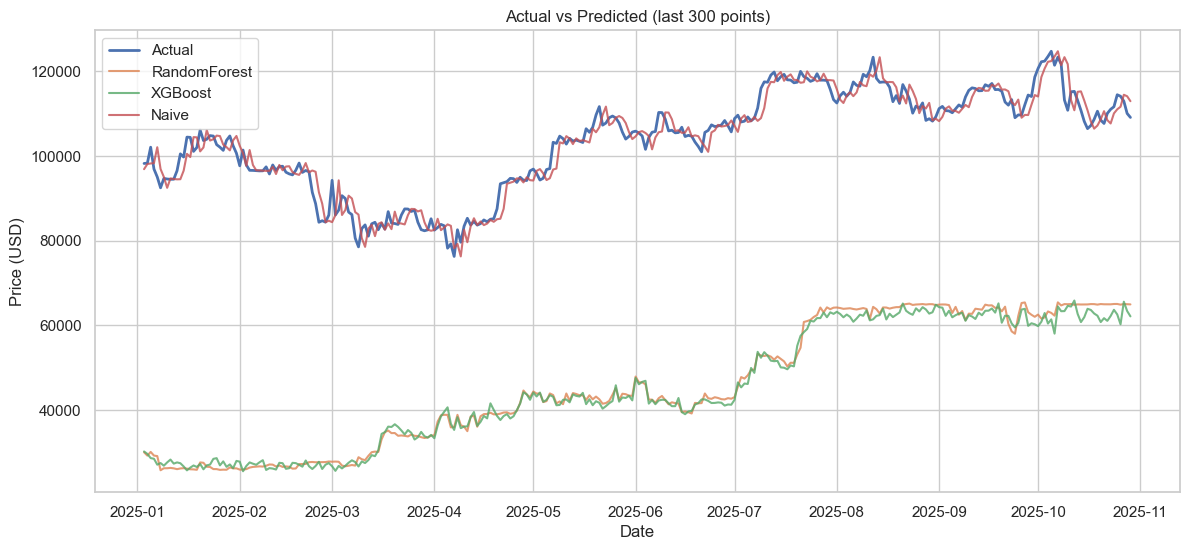

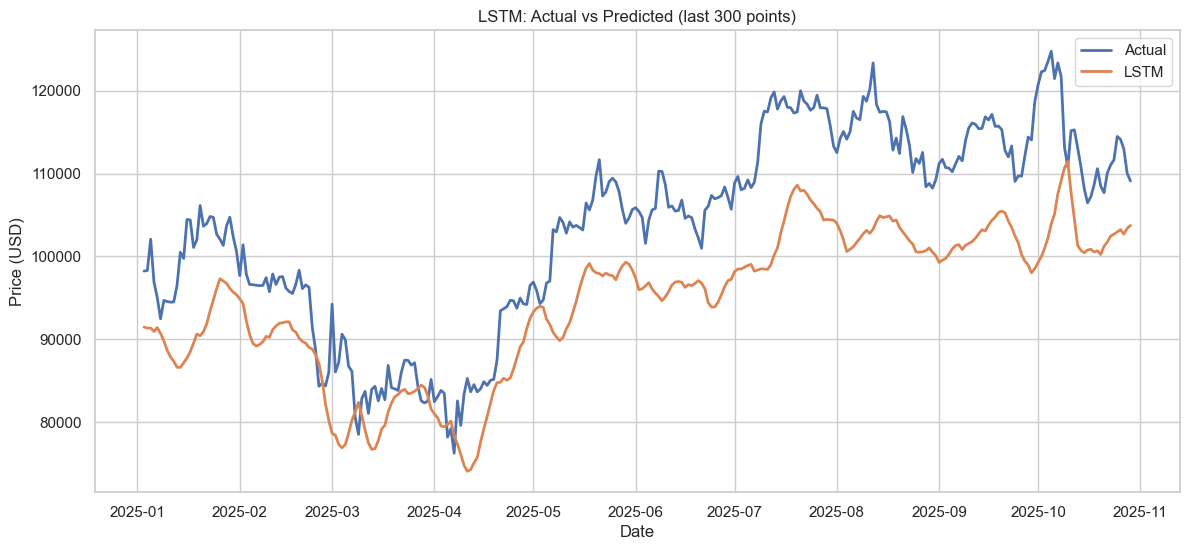

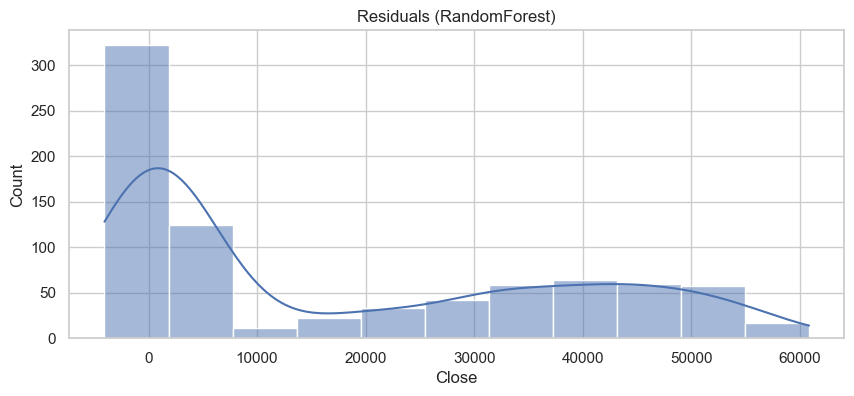

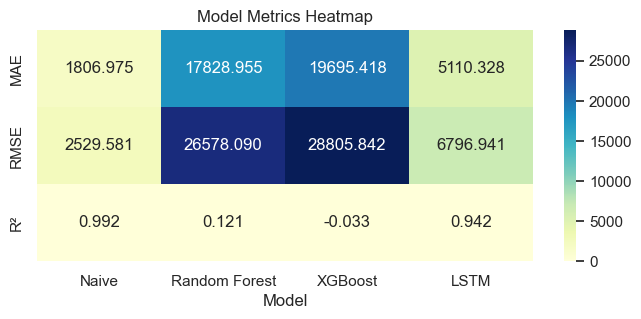

In [11]:
# Plots
N = 300
viz_idx = y_val.index[-N:]

plt.figure(figsize=(14,6))
sns.lineplot(x=viz_idx, y=y_val.loc[viz_idx], label="Actual", linewidth=2)
sns.lineplot(x=viz_idx, y=y_pred_rf[:N], label="RandomForest", alpha=0.8)
sns.lineplot(x=viz_idx, y=y_pred_xgb[:N], label="XGBoost", alpha=0.8)
sns.lineplot(x=viz_idx, y=y_pred_naive_series.loc[viz_idx], label="Naive", alpha=0.8)
plt.title(f"Actual vs Predicted (last {N} points)")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.legend(); plt.show()

plt.figure(figsize=(14,6))
sns.lineplot(x=y_va_series.index[-N:], y=y_va_series[-N:], label="Actual", linewidth=2)
sns.lineplot(x=y_va_series.index[-N:], y=y_pred_lstm_series[-N:], label="LSTM", linewidth=2)
plt.title(f"LSTM: Actual vs Predicted (last {N} points)")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.legend(); plt.show()

plt.figure(figsize=(10,4))
sns.histplot((y_val - y_pred_rf), kde=True)
plt.title("Residuals (RandomForest)")
plt.show()

plt.figure(figsize=(8,3))
sns.heatmap(results.set_index('Model').T, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title("Model Metrics Heatmap")
plt.show()

## 11. Save Metrics & Next Steps
Saving `results` and export the notebook. Next steps: add sentiment features, ensemble methods, and deployment.

In [12]:
results.to_csv("model_comparison_metrics.csv", index=False)
print("Saved metrics to model_comparison_metrics.csv")

Saved metrics to model_comparison_metrics.csv
